# Microsoft Mage-VLをGoogle Colabで動かす v4
## Torch 2.10 + prebuilt Mamba wheel固定版

Microsoftの **`microsoft/Mage-VL`** をGoogle Colabで動かします。

現行Colabの標準環境は、

```text
Python 3.12
PyTorch 2.11
CUDA 12.8
```

ですが、Mamba公式のprebuilt wheelはTorch 2.10までしか揃っていません。

そのため、このv4では、

```text
Colab標準 Torch 2.11
        ↓
Torch 2.10 + cu128へ固定
        ↓
ランタイム再起動
        ↓
causal-conv1d prebuilt wheel
        ↓
mamba-ssm prebuilt wheel
        ↓
Mage-VL
```

という構成にします。

> **重要**
>
> コード3のあとにランタイムが自動再起動します。
> 再接続されたら、**コード4から実行を続けてください。**
>
> FlashAttentionは入れず、Mage-VLは`attn_implementation="sdpa"`で動かします。


In [1]:
# =========================================
# コード1 現在のColab環境を確認
# =========================================
!nvidia-smi -L || echo "No GPU"
!python -V

import sys
import torch
import platform

if not torch.cuda.is_available():
    raise RuntimeError("GPUランタイムを有効にしてください。")

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("Arch:", platform.machine())
print("GPU:", torch.cuda.get_device_name(0))
print(
    "GPU memory: %.2f GB"
    % (
        torch.cuda.get_device_properties(0).total_memory
        / 1024**3
    )
)


GPU 0: Tesla T4 (UUID: GPU-8413fa43-4541-507f-1a34-0b8ee7887558)
Python 3.12.13
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA: 12.8
Arch: x86_64
GPU: Tesla T4
GPU memory: 14.56 GB


## Torch 2.10 + cu128へ固定する

PyTorch公式indexにはPython 3.12 / Linux x86_64向けの

```text
torch-2.10.0+cu128
```

が公開されています。

Mage-VL公式requirementsは`torch>=2.9`なのでTorch 2.10は要件内です。


In [2]:
# =========================================
# コード2 Torch 2.10 / cu128をインストール
# =========================================
%pip install -q --upgrade --force-reinstall \
    torch==2.10.0 \
    torchvision==0.25.0 \
    torchaudio==2.10.0 \
    --index-url https://download.pytorch.org/whl/cu128

print()
print("Torch 2.10のインストールが完了しました。")
print("次のセルでランタイムを再起動します。")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 79.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 147.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 157.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 44.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 37.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 93.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 96.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 88.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 93.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 102.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 59.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 MB 68.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# =========================================
# コード3 ランタイムを再起動
# =========================================
# Torchを入れ替えたため、現在のPythonプロセスを終了します。
# Colabが再接続されたらコード4から続けてください。

import os
import signal

print("ランタイムを再起動します...")
os.kill(os.getpid(), signal.SIGKILL)


# ここから再起動後

Colabが再接続されたら、**コード4から実行してください。**

コード1〜3をもう一度実行する必要はありません。


In [1]:
# =========================================
# コード4 Torch 2.10へ切り替わったか確認
# =========================================
import sys
import torch
import platform

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("Arch:", platform.machine())

if not torch.__version__.startswith("2.10"):
    raise RuntimeError(
        "PyTorch 2.10に切り替わっていません。"
        "コード2 → コード3を再確認してください。"
    )

if torch.version.cuda is None or not torch.version.cuda.startswith("12"):
    raise RuntimeError(
        "CUDA 12系のPyTorchではありません。"
    )

print("Torch 2.10 / CUDA 12 environment: OK")


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA: 12.8
Arch: x86_64
Torch 2.10 / CUDA 12 environment: OK


## causal-conv1d / mamba-ssmをprebuilt wheelで入れる

Mamba公式Issueで、Torch 2.10 / Python 3.12 / CUDA 12向けに動作確認例として示されているwheelを使います。

```text
causal-conv1d 1.6.2.post1
mamba-ssm     2.3.2.post1
```

いずれもsource buildは行いません。


In [2]:
# =========================================
# コード5 prebuilt causal-conv1d / mamba-ssm
# =========================================
import sys
import subprocess

CAUSAL_WHEEL = (
    "https://github.com/Dao-AILab/causal-conv1d/releases/"
    "download/v1.6.2.post1/"
    "causal_conv1d-1.6.2.post1+cu12torch2.10"
    "cxx11abiTRUE-cp312-cp312-linux_x86_64.whl"
)

MAMBA_WHEEL = (
    "https://github.com/state-spaces/mamba/releases/"
    "download/v2.3.2.post1/"
    "mamba_ssm-2.3.2.post1+cu12torch2.10"
    "cxx11abiTRUE-cp312-cp312-linux_x86_64.whl"
)

print("Installing causal-conv1d wheel:")
print(CAUSAL_WHEEL)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        CAUSAL_WHEEL,
    ]
)

print("Installing mamba-ssm wheel:")
print(MAMBA_WHEEL)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        MAMBA_WHEEL,
    ]
)

print("prebuilt wheels installed")


Installing causal-conv1d wheel:
https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.6.2.post1/causal_conv1d-1.6.2.post1+cu12torch2.10cxx11abiTRUE-cp312-cp312-linux_x86_64.whl
Installing mamba-ssm wheel:
https://github.com/state-spaces/mamba/releases/download/v2.3.2.post1/mamba_ssm-2.3.2.post1+cu12torch2.10cxx11abiTRUE-cp312-cp312-linux_x86_64.whl
prebuilt wheels installed


In [3]:
# =========================================
# コード6 CUDA extensionのimport確認
# =========================================
import causal_conv1d
import mamba_ssm

print(
    "causal_conv1d:",
    getattr(
        causal_conv1d,
        "__version__",
        "version unavailable",
    ),
)

print(
    "mamba_ssm:",
    getattr(
        mamba_ssm,
        "__version__",
        "version unavailable",
    ),
)

print("Mamba CUDA extensions imported successfully")


causal_conv1d: 1.6.2.post1
mamba_ssm: 2.3.2.post1
Mamba CUDA extensions imported successfully


In [4]:
# =========================================
# コード7 Mage-VL用の基本ライブラリ
# =========================================
# Torchは変更しない
%pip -q install -U \
    "transformers>=5.7" \
    accelerate \
    bitsandbytes \
    opencv-python-headless \
    requests \
    packaging

import transformers
import PIL

print("Transformers:", transformers.__version__)
print("Pillow:", PIL.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.7.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.7.0 which is incompatible.
Transformers: 5.15.0
Pillow: 12.3.0


In [5]:
# =========================================
# コード8 Google Drive / Hugging Face cache
# =========================================
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os
import shutil

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/LocalLLM"
)

CACHE_DIR = (
    PROJECT_DIR
    / "Program"
    / "hf_cache_mage_vl"
)

CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

os.environ["HF_HUB_CACHE"] = str(CACHE_DIR)
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

print("CACHE_DIR:", CACHE_DIR)
print(
    "Drive free: %.1f GB"
    % (
        shutil.disk_usage(CACHE_DIR).free
        / 1024**3
    )
)


Mounted at /content/drive
CACHE_DIR: /content/drive/MyDrive/Colab Notebooks/LocalLLM/Program/hf_cache_mage_vl
Drive free: 14.9 GB


## Mage-VLをNF4 4bitでロード

無料版T4を想定して、bitsandbytes NF4 4bitを利用します。

FlashAttentionは使わず、

```python
attn_implementation="sdpa"
```

を指定します。


In [6]:
# =========================================
# コード9 Mage-VLをNF4 4bitでロード
# =========================================
import torch

from transformers import (
    AutoProcessor,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)

MODEL_ID = "microsoft/Mage-VL"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    cache_dir=str(CACHE_DIR),
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    quantization_config=bnb_config,
    device_map="auto",
    cache_dir=str(CACHE_DIR),
    low_cpu_mem_usage=True,
    attn_implementation="sdpa",
)

model.eval()

INPUT_DEVICE = next(model.parameters()).device

print("model loaded:", MODEL_ID)
print("input device:", INPUT_DEVICE)
print("4bit:", getattr(model, "is_loaded_in_4bit", False))
print("device map:", getattr(model, "hf_device_map", "N/A"))

print(
    "GPU allocated: %.2f GB"
    % (
        torch.cuda.memory_allocated()
        / 1024**3
    )
)
print(
    "GPU reserved : %.2f GB"
    % (
        torch.cuda.memory_reserved()
        / 1024**3
    )
)


preprocessor_config.json:   0%|          | 0.00/1.81k [00:00<?, ?B/s]

processing_mage_vl.py:   0%|          | 0.00/25.5k [00:00<?, ?B/s]

codec_video_processing_mage_vl.py:   0%|          | 0.00/26.4k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/microsoft/Mage-VL:
- codec_video_processing_mage_vl.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


video_processing_mage_vl.py:   0%|          | 0.00/28.4k [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/696 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

model loaded: microsoft/Mage-VL
input device: cuda:0
4bit: True
device map: N/A
GPU allocated: 3.39 GB
GPU reserved : 3.42 GB


In [7]:
# =========================================
# コード10 公開サンプル画像
# =========================================
from PIL import Image
from pathlib import Path
from IPython.display import display
import requests

SAMPLE_DIR = Path("/content/mage_vl_samples")
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_URL = (
    "https://raw.githubusercontent.com/"
    "microsoft/Mage/main/"
    "mage_vl/assets/examples/dog.jpg"
)

SAMPLE_PATH = SAMPLE_DIR / "dog.jpg"

r = requests.get(SAMPLE_URL, timeout=120)
r.raise_for_status()
SAMPLE_PATH.write_bytes(r.content)

sample_image = Image.open(
    SAMPLE_PATH
).convert("RGB")

print("image:", SAMPLE_PATH)
print("size:", sample_image.size)
display(sample_image)


Output hidden; open in https://colab.research.google.com to view.

In [8]:
# =========================================
# コード11 画像生成関数
# =========================================
import gc
import torch

@torch.inference_mode()
def mage_image_generate(
    image,
    question=(
        "この画像に何が写っているか、"
        "日本語で説明してください。"
    ),
    max_new_tokens=256,
):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": question},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt",
    )

    print(
        "processor keys:",
        list(inputs.keys()),
    )

    for key, value in inputs.items():
        if hasattr(value, "shape"):
            print(
                key,
                tuple(value.shape),
                value.dtype,
            )

    inputs = {
        k: (
            v.to(INPUT_DEVICE)
            if hasattr(v, "to")
            else v
        )
        for k, v in inputs.items()
    }

    if "pixel_values" in inputs:
        try:
            inputs["pixel_values"] = (
                inputs["pixel_values"]
                .to(model.dtype)
            )
        except Exception:
            pass

    outputs = model.generate(
        **inputs,
        max_new_tokens=int(max_new_tokens),
        do_sample=False,
    )

    generated = outputs[
        0,
        inputs["input_ids"].shape[1]:
    ]

    answer = processor.tokenizer.decode(
        generated,
        skip_special_tokens=True,
    ).strip()

    del inputs, outputs, generated
    gc.collect()
    torch.cuda.empty_cache()

    return answer


In [9]:
# =========================================
# コード12 画像理解テスト
# =========================================
print(
    mage_image_generate(
        sample_image,
        (
            "この画像に何が写っているか、"
            "日本語で具体的に説明してください。"
        ),
        max_new_tokens=192,
    )
)


processor keys: ['pixel_values', 'image_grid_thw', 'patch_positions', 'input_ids', 'attention_mask']
pixel_values (8192, 768) torch.float32
image_grid_thw (1, 3) torch.int64
patch_positions (8192, 3) torch.int64
input_ids (1, 2088) torch.int64
attention_mask (1, 2088) torch.int64


[transformers] The remote code model you are currently using seems to expect `cache_position`. This arg has been removed from the Transformers library, and will stop being created in `generate` even for remote code models in a future release. Please open a PR on the remote code hub repo to remove any usage of `cache_position`.


この画像には、白と黒の混合毛色を持つ犬が写っています。犬の顔は正面に向け、大きな瞳が見えており、口元には少し笑みが浮かんでいます。背景には、赤と青の色調が特徴的な絨毯が掛かっています。


## 自分の画像で試す

次のセルで画像をアップロードできます。


Saving スクリーンショット 2026-08-20 0.08.57.png to スクリーンショット 2026-08-20 0.08.57.png


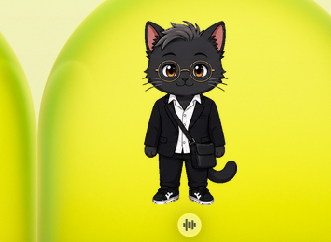

processor keys: ['pixel_values', 'image_grid_thw', 'patch_positions', 'input_ids', 'attention_mask']
pixel_values (320, 768) torch.float32
image_grid_thw (1, 3) torch.int64
patch_positions (320, 3) torch.int64
input_ids (1, 128) torch.int64
attention_mask (1, 128) torch.int64
対象：黒い猫のキャラクター
背景：黄色の壁
文字：なし
状況：黒い猫のキャラクターが黄色の壁の前で立っている。


In [10]:
# =========================================
# コード13 自分の画像
# =========================================
from google.colab import files
from PIL import Image
from pathlib import Path
from IPython.display import display

uploaded = files.upload()

if not uploaded:
    raise RuntimeError(
        "画像がアップロードされませんでした。"
    )

filename = next(iter(uploaded.keys()))
USER_IMAGE_PATH = Path("/content") / filename
USER_IMAGE_PATH.write_bytes(uploaded[filename])

user_image = Image.open(
    USER_IMAGE_PATH
).convert("RGB")

display(user_image)

print(
    mage_image_generate(
        user_image,
        (
            "この画像を注意深く見て、"
            "対象、背景、文字、状況を"
            "日本語で説明してください。"
        ),
        max_new_tokens=256,
    )
)


# Frame-sampled video

無料版T4では、まず8 framesで動画理解を試します。


In [11]:
# =========================================
# コード14 動画アップロード
# =========================================
from google.colab import files
from pathlib import Path

print("短いMP4動画をアップロードしてください。")

uploaded_video = files.upload()

if not uploaded_video:
    raise RuntimeError(
        "動画がアップロードされませんでした。"
    )

video_name = next(iter(uploaded_video.keys()))
VIDEO_PATH = Path("/content") / video_name
VIDEO_PATH.write_bytes(uploaded_video[video_name])

print("video:", VIDEO_PATH)
print(
    "size: %.2f MB"
    % (
        VIDEO_PATH.stat().st_size
        / 1024**2
    )
)


短いMP4動画をアップロードしてください。


Saving soccer-broadcast.mp4 to soccer-broadcast.mp4
video: /content/soccer-broadcast.mp4
size: 3.73 MB


In [12]:
# =========================================
# コード15 動画から8 framesを抽出
# =========================================
import cv2
import numpy as np
from PIL import Image

def sample_video(
    video_path,
    num_frames=8,
):
    cap = cv2.VideoCapture(str(video_path))
    count = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if count <= 0:
        cap.release()
        raise ValueError("動画を読めません。")

    indices = np.linspace(
        0,
        count - 1,
        min(num_frames, count),
        dtype=int,
    )

    frames = []

    for idx in indices:
        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(idx),
        )
        ok, frame = cap.read()

        if not ok:
            cap.release()
            raise ValueError(
                f"frame {idx}を取得できません。"
            )

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB,
        )

        frames.append(
            Image.fromarray(frame)
        )

    cap.release()
    return frames

video_frames = sample_video(
    VIDEO_PATH,
    num_frames=8,
)

print(
    "sampled frames:",
    len(video_frames),
)


sampled frames: 8


In [13]:
# =========================================
# コード16 Frame-sampled video生成
# =========================================
import gc
import torch

@torch.inference_mode()
def mage_video_generate(
    frames,
    question=(
        "この動画で何が起きているか、"
        "日本語で説明してください。"
    ),
    max_new_tokens=256,
):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "video"},
                {"type": "text", "text": question},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = processor(
        text=[text],
        videos=[frames],
        return_tensors="pt",
        padding=True,
    )

    print(
        "processor keys:",
        list(inputs.keys()),
    )

    inputs = {
        k: (
            v.to(INPUT_DEVICE)
            if hasattr(v, "to")
            else v
        )
        for k, v in inputs.items()
    }

    if "pixel_values" in inputs:
        try:
            inputs["pixel_values"] = (
                inputs["pixel_values"]
                .to(model.dtype)
            )
        except Exception:
            pass

    outputs = model.generate(
        **inputs,
        max_new_tokens=int(max_new_tokens),
        do_sample=False,
    )

    generated = outputs[
        0,
        inputs["input_ids"].shape[1]:
    ]

    answer = processor.tokenizer.decode(
        generated,
        skip_special_tokens=True,
    ).strip()

    del inputs, outputs, generated
    gc.collect()
    torch.cuda.empty_cache()

    return answer

print(
    mage_video_generate(
        video_frames,
        max_new_tokens=256,
    )
)


processor keys: ['pixel_values', 'image_grid_thw', 'patch_positions', 'input_ids', 'attention_mask']
この動画は、BBC Sportが放送する英語とアルジェリアの国際A级試合の試合後の分析やレポートを提供するためのスタジアムでのアナウンサーのインタビューの様子を描いたものです。試合終了後、アナウンサーたちは試合の結果や試合の様子について話し合う場面が描かれています。


# Optional: codec-native video

ここからはMage-VLの特徴的なcodec-native経路です。

まずframe-sampled videoが正常に動いた後に実行してください。


In [14]:
# =========================================
# コード17 codec-native依存関係
# =========================================
!apt-get -qq update
!apt-get -qq install -y ffmpeg

%pip -q install -U "codec-video-prep>=0.2.5"

import shutil

print("ffmpeg:", shutil.which("ffmpeg"))
print("ffprobe:", shutil.which("ffprobe"))
print("cv-preinfer:", shutil.which("cv-preinfer"))


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 18.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>

In [15]:
# =========================================
# コード18 codec-native video test
# =========================================
import gc
import torch

@torch.inference_mode()
def mage_codec_video_generate(
    video_path,
    question=(
        "この動画の内容を"
        "日本語で説明してください。"
    ),
    num_frames=8,
    max_pixels=100000,
    max_new_tokens=256,
):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "video"},
                {"type": "text", "text": question},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    codec_config = {
        "engine": "hevc",
        "target_canvas": int(num_frames),
        "patch": 16,
    }

    inputs = processor(
        text=[text],
        videos=[str(video_path)],
        video_backend="codec",
        max_pixels=int(max_pixels),
        codec_config=codec_config,
        return_tensors="pt",
        padding=True,
    )

    inputs = {
        k: (
            v.to(INPUT_DEVICE)
            if hasattr(v, "to")
            else v
        )
        for k, v in inputs.items()
    }

    if "pixel_values" in inputs:
        try:
            inputs["pixel_values"] = (
                inputs["pixel_values"]
                .to(model.dtype)
            )
        except Exception:
            pass

    outputs = model.generate(
        **inputs,
        max_new_tokens=int(max_new_tokens),
        do_sample=False,
    )

    generated = outputs[
        0,
        inputs["input_ids"].shape[1]:
    ]

    answer = processor.tokenizer.decode(
        generated,
        skip_special_tokens=True,
    ).strip()

    del inputs, outputs, generated
    gc.collect()
    torch.cuda.empty_cache()

    return answer

print(
    mage_codec_video_generate(
        VIDEO_PATH,
        max_new_tokens=256,
    )
)


0.0秒から27.0秒までの動画は、スポーツイベントのスタジアムで行われているラジオ番組の取材や分析の様子を描いたものです。スタジアムの観客席が広大で、多くの人々が座っていることがわかります。スタジアムの背景には「ATLANTA」の看板が掲げられています。スタジアムの上部には「BBB SPORTS」のロゴが表示されています。スタジアムの下部には「BBB SPORTS」のロゴが表示されています。スタジアムの下部には「BBB SPORTS」のロゴが表示されています。スタジアムの下部には「BBB SPORTS」のロゴが表示されています。スタジアムの下部には「BBB SPORTS」のロゴが表示されています。スタジアムの下部には「BBB SPORTS」のロゴが表示されています。スタジアムの下部には「BBB SPORTS」のロゴが表示されています。スタジアムの下部には「BBB SPORTS」のロゴが表示されています。


# Gradio画像UI

最後に書籍と同じ流れで、画像質問用のシンプルなGradio UIを作ります。


In [16]:
# =========================================
# コード19 Gradio Image UI
# =========================================
import gradio as gr
from PIL import Image
import traceback
import gc
import torch

print("Gradio:", gr.__version__)

def gradio_mage(
    image,
    question,
):
    if image is None:
        raise gr.Error(
            "画像を指定してください。"
        )

    if not (question or "").strip():
        question = (
            "この画像に何が写っているか、"
            "日本語で説明してください。"
        )

    try:
        return mage_image_generate(
            image.convert("RGB"),
            question,
            max_new_tokens=192,
        )
    except Exception as e:
        traceback.print_exc()
        gc.collect()
        torch.cuda.empty_cache()

        raise gr.Error(
            f"{type(e).__name__}: {e}"
        ) from e

with gr.Blocks(
    title="Microsoft Mage-VL"
) as demo:

    gr.Markdown(
        "## Microsoft Mage-VL "
        "— Google Colab Vision Chat"
    )

    with gr.Row():

        image_box = gr.Image(
            type="pil",
            label="Image",
        )

        with gr.Column():

            question_box = gr.Textbox(
                label="Question",
                value=(
                    "この画像に何が写っているか、"
                    "日本語で具体的に"
                    "説明してください。"
                ),
                lines=4,
            )

            run_button = gr.Button(
                "Run",
                variant="primary",
            )

    output_box = gr.Textbox(
        label="Answer",
        lines=10,
    )

    run_button.click(
        gradio_mage,
        inputs=[
            image_box,
            question_box,
        ],
        outputs=output_box,
        concurrency_limit=1,
    )

demo.queue(
    default_concurrency_limit=1
)

demo.launch(
    share=True,
    inline=True,
    debug=False,
    show_error=True,
)


Gradio: 6.24.0
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9f34567a519cff2e9f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [17]:
# =========================================
# コード20 最終GPUメモリ
# =========================================
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

print(
    "GPU allocated: %.2f GB"
    % (
        torch.cuda.memory_allocated()
        / 1024**3
    )
)

print(
    "GPU reserved : %.2f GB"
    % (
        torch.cuda.memory_reserved()
        / 1024**3
    )
)

free, total = torch.cuda.mem_get_info()

print(
    "GPU free      : %.2f GB"
    % (
        free / 1024**3
    )
)

print(
    "GPU total     : %.2f GB"
    % (
        total / 1024**3
    )
)


GPU allocated: 3.41 GB
GPU reserved : 3.45 GB
GPU free      : 10.98 GB
GPU total     : 14.56 GB


## 関連書籍

このNotebookは書籍の公式サンプルそのものではありません。

『ブラウザで動かすLLM実装入門　Google Colaboratoryで実践するLLM・RAG・ファインチューニング』で扱った、

```text
Google Colab
モデルロード
量子化
推論関数
Gradio UI
```

という基本構成を、新しく公開されたMage-VLへ適用した追加実験です。

https://amzn.asia/d/0dV4aYtC
